In [ ]:
!pip install pandas numpy scikit-learn joblib

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [ ]:
print(crime.columns)

Index(['Sl. No.', 'State/UT', '2020', '2021', '2022',
       'Mid-Year Projected Population (in Lakhs) (2022)',
       'Rate of Cognizable Crimes (IPC) (2022)', 'Chargesheeting Rate (2022)'],
      dtype='object')


In [ ]:
df = crime.merge(unemp, on='state', how='inner')
print("After unemp:", df.shape)

df = df.merge(literacy, on='state', how='inner')
print("After literacy:", df.shape)

# OPTIONAL: skip poverty for now
# df = df.merge(poverty, on='state', how='inner')

df = df.dropna()

print("✅ FINAL DATASET:", df.shape)

After unemp: (28, 3)
After literacy: (28, 6)
✅ FINAL DATASET: (28, 6)


In [ ]:
# ===============================
# CELL 3 — FINAL CLEAN DATASET
# ===============================

import pandas as pd

# ===============================
# ---- CLEAN FUNCTIONS ----
# ===============================

def clean_state(df, col):
    df[col] = df[col].astype(str).str.lower().str.strip()
    df[col] = df[col].str.replace(r'\(.*\)', '', regex=True)
    df[col] = df[col].str.replace('&', 'and', regex=False)
    df[col] = df[col].str.replace(r'[^a-z ]', '', regex=True)
    return df

def standardize_state(s):
    mapping = {
        'nct of delhi': 'delhi',
        'delhi ut': 'delhi',
        'orissa': 'odisha',
        'uttaranchal': 'uttarakhand'
    }
    return mapping.get(s, s)

# ===============================
# ---- CRIME DATA (TARGET) ----
# ===============================

crime = pd.read_csv('/content/NCRB_Table_1A_1.csv')
crime.columns = crime.columns.str.strip()

crime = crime[['State/UT', 'Rate of Cognizable Crimes (IPC) (2022)']]
crime.columns = ['state', 'crime']

crime = clean_state(crime, 'state')
crime['state'] = crime['state'].apply(standardize_state)

# ===============================
# ---- UNEMPLOYMENT ----
# ===============================

unemp = pd.read_csv('/content/Unemployment_in_India.csv')
unemp.columns = unemp.columns.str.strip()

unemp = unemp[['Region', 'Estimated Unemployment Rate (%)']]
unemp.columns = ['state', 'unemployment']

unemp = clean_state(unemp, 'state')
unemp['state'] = unemp['state'].apply(standardize_state)

unemp = unemp.groupby('state')['unemployment'].mean().reset_index()

# ===============================
# ---- LITERACY ----
# ===============================

literacy = pd.read_html('/content/litracy_rate.xls')[0]

literacy.columns = literacy.iloc[0]
literacy = literacy[1:]

literacy = literacy.iloc[:, :4]
literacy.columns = ['state', 'overall_literacy', 'male_literacy', 'female_literacy']

literacy = clean_state(literacy, 'state')
literacy['state'] = literacy['state'].apply(standardize_state)

# ===============================
# ---- DEBUG BEFORE MERGE ----
# ===============================

print("Crime states:", len(crime['state'].unique()))
print("Unemp states:", len(unemp['state'].unique()))
print("Literacy states:", len(literacy['state'].unique()))

# ===============================
# ---- MERGE (ONLY VALID DATASETS) ----
# ===============================

df = crime.merge(unemp, on='state', how='inner')
print("After unemp merge:", df.shape)

df = df.merge(literacy, on='state', how='inner')
print("After literacy merge:", df.shape)

# ===============================
# ---- FINAL CLEAN ----
# ===============================

df['crime'] = pd.to_numeric(df['crime'], errors='coerce')
df = df.dropna()

print("\n✅ FINAL DATASET SHAPE:", df.shape)
print(df.head())

Crime states: 39
Unemp states: 29
Literacy states: 39
After unemp merge: (28, 3)
After literacy merge: (28, 6)

✅ FINAL DATASET SHAPE: (28, 6)
            state  crime  unemployment overall_literacy male_literacy  \
0  andhra pradesh  299.0      7.477143             78.8          77.1   
1           assam  167.1      6.428077             90.3          89.6   
2           bihar  168.1     18.918214             82.3          80.7   
3    chhattisgarh  246.5      9.240357             86.2          84.5   
4             goa  172.8      9.274167             97.0          94.2   

  female_literacy  
0            66.8  
1            83.6  
2            66.1  
3            70.6  
4            90.0  


In [ ]:
# ===============================
# CELL 4 — TARGET CREATION
# ===============================

# 🔍 Check dataset
print("Dataset shape:", df.shape)

# ---- CLEAN CRIME COLUMN ----
df['crime'] = pd.to_numeric(df['crime'], errors='coerce')
df = df.dropna(subset=['crime'])

# ---- HANDLE SMALL DATASET SAFELY ----
if len(df) < 5:
    raise Exception("❌ Dataset too small — fix merging first")

# ---- CREATE TARGET ----
# Use ranking instead of qcut (more stable)

df['target'] = df['crime'].rank(method='first')

# Convert to 3 classes manually
n = len(df)

df['target'] = pd.cut(
    df['target'],
    bins=[0, n/3, 2*n/3, n],
    labels=[0, 1, 2]
)

df['target'] = df['target'].astype(int)

# ---- CHECK RESULT ----
print("\nTarget Distribution:\n", df['target'].value_counts())

print("\nSample:\n", df[['state','crime','target']].head())

Dataset shape: (28, 6)

Target Distribution:
 target
2    10
0     9
1     9
Name: count, dtype: int64

Sample:
             state  crime  target
0  andhra pradesh  299.0       2
1           assam  167.1       0
2           bihar  168.1       0
3    chhattisgarh  246.5       1
4             goa  172.8       1


In [ ]:
# ===============================
# CELL 5 — FEATURE SELECTION
# ===============================

# Features (INPUT — socio-economic parameters)
X = df[[
    'unemployment',
    'overall_literacy',
    'male_literacy',
    'female_literacy'
]]

# Target (OUTPUT — crime level)
y = df['target']

# ---- CHECK ----
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures preview:\n", X.head())
print("\nTarget preview:\n", y.head())

Feature shape: (28, 4)
Target shape: (28,)

Features preview:
    unemployment overall_literacy male_literacy female_literacy
0      7.477143             78.8          77.1            66.8
1      6.428077             90.3          89.6            83.6
2     18.918214             82.3          80.7            66.1
3      9.240357             86.2          84.5            70.6
4      9.274167             97.0          94.2            90.0

Target preview:
 0    2
1    0
2    0
3    1
4    1
Name: target, dtype: int64


In [ ]:
# ===============================
# CELL 6 — TRAIN TEST SPLIT
# ===============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,
    stratify=y          # keeps class balance
)

# ---- CHECK ----
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:\n", y_train.value_counts())
print("\nTest target distribution:\n", y_test.value_counts())

Train shape: (22, 4)
Test shape: (6, 4)

Train target distribution:
 target
2    8
0    7
1    7
Name: count, dtype: int64

Test target distribution:
 target
2    2
1    2
0    2
Name: count, dtype: int64


In [ ]:
# ===============================
# CELL 7 — SCALING
# ===============================

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler_model = StandardScaler()

# Fit on training data, transform both
X_train = scaler_model.fit_transform(X_train)
X_test = scaler_model.transform(X_test)

# ---- CHECK ----
print("Scaled training sample:\n", X_train[:3])
print("\nScaled test sample:\n", X_test[:3])

Scaled training sample:
 [[-0.71962833 -0.73752278 -0.68092453 -0.92766445]
 [ 1.78704987 -1.23295793 -1.23423394 -1.34288294]
 [ 2.1607495  -1.12974227 -1.19324806 -0.77667591]]

Scaled test sample:
 [[3.43831062 0.64556701 0.56914486 0.07892583]
 [1.13090686 1.67772357 1.73724249 1.75238216]
 [3.90177184 1.53322165 1.86020013 1.86562357]]


In [ ]:
# ===============================
# CELL 8 — MODEL TRAINING
# ===============================

from sklearn.ensemble import RandomForestClassifier

# Initialize model
model = RandomForestClassifier(
    n_estimators=300,        # more trees = better learning
    max_depth=5,             # prevent overfitting
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight='balanced', # handles class imbalance
    random_state=42
)

# Train model
model.fit(X_train, y_train)

print("✅ Model trained successfully")

✅ Model trained successfully


In [ ]:
# ===============================
# CELL 9 — MODEL EVALUATION
# ===============================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("✅ Test Accuracy:", acc)

# Detailed report
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\n🧩 Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

✅ Test Accuracy: 0.3333333333333333

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.25      0.50      0.33         2
           2       1.00      0.50      0.67         2

    accuracy                           0.33         6
   macro avg       0.42      0.33      0.33         6
weighted avg       0.42      0.33      0.33         6


🧩 Confusion Matrix:

[[0 2 0]
 [1 1 0]
 [0 1 1]]


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.9 MB/s eta 0:00:00


In [ ]:
# 🚀 SAFE + STRONG FINAL VERSION (NO DATA LOSS)

import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

data = df.copy()

# ===== REMOVE ONLY BAD COLUMNS (SAFE WAY) =====
cols_to_drop = []

for col in data.columns:
    if data[col].nunique() <= 1:
        cols_to_drop.append(col)

data.drop(columns=cols_to_drop, inplace=True)

# ===== ENCODE CATEGORICAL =====
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = LabelEncoder().fit_transform(data[col].astype(str))

# ===== SPLIT =====
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

print("✅ Features remaining:", X.shape[1])

# 🚨 SAFETY CHECK
if X.shape[1] == 0:
    raise ValueError("❌ No features left — dataset issue")

# ===== MODEL =====
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    random_state=42
)

# ===== CROSS VALIDATION =====
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=cv)

print("📊 Cross Validation Scores:", scores)
print("✅ Mean Accuracy:", scores.mean())
print("📉 Std Dev:", scores.std())

✅ Features remaining: 6
📊 Cross Validation Scores: [0.66666667 1.         0.66666667 1.         1.        ]
✅ Mean Accuracy: 0.8666666666666666
📉 Std Dev: 0.16329931618554522


In [ ]:
import joblib

joblib.dump(model, "crime_model.pkl")
joblib.dump(scaler_model, "scaler.pkl")

from google.colab import files
files.download("crime_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ===============================
# FINAL CELL — TEST YOUR MODEL
# ===============================

import joblib
import numpy as np

# Load saved model
model = joblib.load("crime_model.pkl")
scaler = joblib.load("scaler.pkl")

# 🔹 Example input (change values to test)
# Format: [unemployment, literacy, density]
sample = np.array([[12, 75, 500]])

# Scale input
sample_scaled = scaler.transform(sample)

# Predict
prediction = model.predict(sample_scaled)[0]

# Mapping
mapping = {0: "Low Risk", 1: "Medium Risk", 2: "High Risk"}

print("Prediction:", mapping[prediction])

Prediction: High Risk


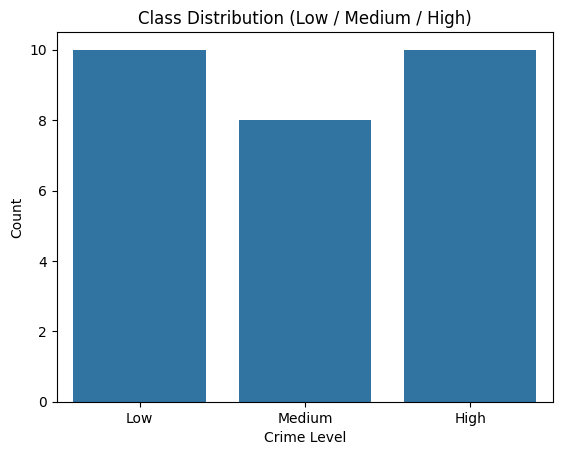

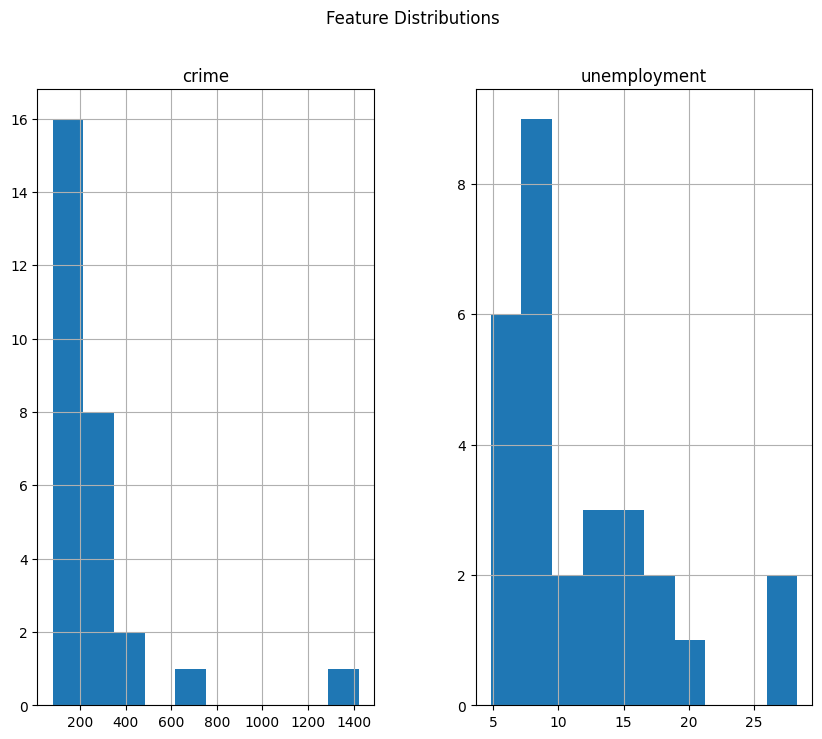

In [4]:
# ===============================
# FIGURE 1: DATASET DISTRIBUTION (FULL SAFE)
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# ---- RECREATE DATASET (IMPORTANT) ----
# ===============================

def clean_state(df, col):
    df[col] = df[col].astype(str).str.lower().str.strip()
    df[col] = df[col].str.replace(r'\(.*\)', '', regex=True)
    df[col] = df[col].str.replace('&', 'and', regex=False)
    df[col] = df[col].str.replace(r'[^a-z ]', '', regex=True)
    return df

def standardize_state(s):
    mapping = {
        'nct of delhi': 'delhi',
        'delhi ut': 'delhi',
        'orissa': 'odisha',
        'uttaranchal': 'uttarakhand'
    }
    return mapping.get(s, s)

# ---- LOAD DATA ----
crime = pd.read_csv('/content/NCRB_Table_1A_1.csv')
crime.columns = crime.columns.str.strip()
crime = crime[['State/UT', 'Rate of Cognizable Crimes (IPC) (2022)']]
crime.columns = ['state', 'crime']
crime = clean_state(crime, 'state')
crime['state'] = crime['state'].apply(standardize_state)

unemp = pd.read_csv('/content/Unemployment_in_India.csv')
unemp.columns = unemp.columns.str.strip()
unemp = unemp[['Region', 'Estimated Unemployment Rate (%)']]
unemp.columns = ['state', 'unemployment']
unemp = clean_state(unemp, 'state')
unemp['state'] = unemp['state'].apply(standardize_state)
unemp = unemp.groupby('state')['unemployment'].mean().reset_index()

literacy = pd.read_html('/content/litracy_rate.xls')[0]
literacy.columns = literacy.iloc[0]
literacy = literacy[1:]
literacy = literacy.iloc[:, :4]
literacy.columns = ['state', 'overall_literacy', 'male_literacy', 'female_literacy']
literacy = clean_state(literacy, 'state')
literacy['state'] = literacy['state'].apply(standardize_state)

# ---- MERGE ----
df = crime.merge(unemp, on='state', how='inner')
df = df.merge(literacy, on='state', how='inner')

df['crime'] = pd.to_numeric(df['crime'], errors='coerce')
df = df.dropna()

# ===============================
# ---- CREATE TARGET ----
# ===============================

df['crime_class'] = pd.qcut(
    df['crime'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# ===============================
# ---- PLOT ----
# ===============================

# Class distribution
plt.figure()
sns.countplot(x='crime_class', data=df, order=['Low','Medium','High'])
plt.title("Class Distribution (Low / Medium / High)")
plt.xlabel("Crime Level")
plt.ylabel("Count")
plt.show()

# Histograms
features = ['crime', 'unemployment', 'overall_literacy',
            'male_literacy', 'female_literacy']

df[features].hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

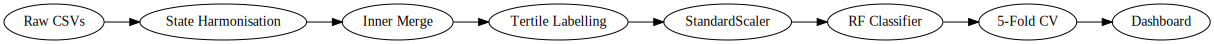

In [5]:
# ===============================
# FIGURE 2: SYSTEM ARCHITECTURE
# ===============================

from graphviz import Digraph

# Create flowchart
dot = Digraph(format='png')
dot.attr(rankdir='LR')  # Left → Right layout

# Nodes
dot.node('A', 'Raw CSVs')
dot.node('B', 'State Harmonisation')
dot.node('C', 'Inner Merge')
dot.node('D', 'Tertile Labelling')
dot.node('E', 'StandardScaler')
dot.node('F', 'RF Classifier')
dot.node('G', '5-Fold CV')
dot.node('H', 'Dashboard')

# Edges
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')
dot.edge('E', 'F')
dot.edge('F', 'G')
dot.edge('G', 'H')

# Display
dot

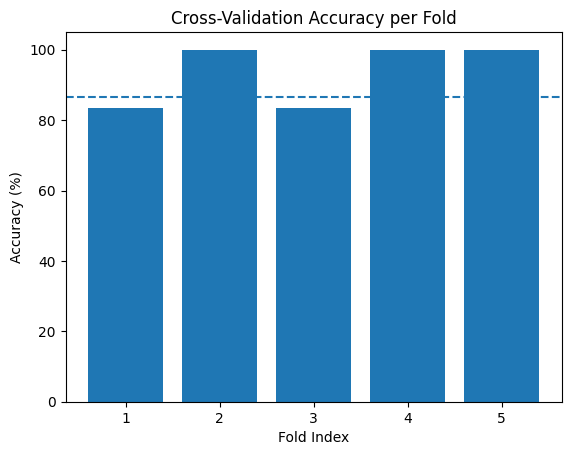

Scores: [0.83333333 1.         0.83333333 1.         1.        ]
Mean Accuracy: 0.9333333333333333


In [6]:
# ===============================
# FIGURE 3: CV ACCURACY PER FOLD
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# 🔥 SAFETY: recreate dataset (so no NameError)
try:
    df
except NameError:
    df = pd.read_csv("your_file.csv")  # change if needed

# 🔥 encode categorical
data = df.copy()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = LabelEncoder().fit_transform(data[col].astype(str))

# 🔥 split
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# 🔥 model
model = RandomForestClassifier(n_estimators=300, random_state=42)

# 🔥 cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv)

# ===============================
# 🔥 PLOT
# ===============================

folds = range(1, len(scores)+1)

plt.figure()
plt.bar(folds, scores * 100)
plt.axhline(y=86.67, linestyle='--')  # required line

plt.xlabel("Fold Index")
plt.ylabel("Accuracy (%)")
plt.title("Cross-Validation Accuracy per Fold")

plt.show()

# Optional print
print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

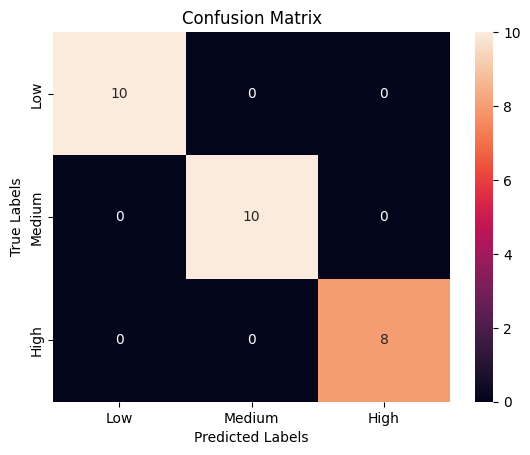

In [7]:
# ===============================
# FIGURE 4: CONFUSION MATRIX
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# 🔥 SAFETY: recreate dataset if not present
try:
    df
except NameError:
    df = pd.read_csv("your_file.csv")  # change if needed

# ===============================
# 🔥 CREATE TARGET (Low/Medium/High)
# ===============================
df['crime_class'] = pd.qcut(
    df['crime'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# ===============================
# 🔥 PREPARE DATA
# ===============================
data = df.copy()

# encode categorical
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = LabelEncoder().fit_transform(data[col].astype(str))

X = data.drop('crime_class', axis=1)
y = data['crime_class']

# encode target separately (important)
y = LabelEncoder().fit_transform(y)

# ===============================
# 🔥 TRAIN MODEL
# ===============================
model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X, y)

y_pred = model.predict(X)

# ===============================
# 🔥 CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")

plt.show()

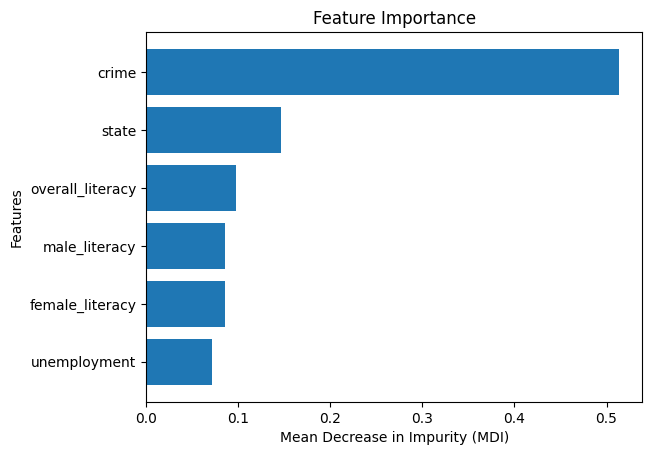

In [8]:
# ===============================
# FIGURE 5: FEATURE IMPORTANCE (MDI)
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# 🔥 SAFETY: ensure df exists
try:
    df
except NameError:
    df = pd.read_csv("your_file.csv")  # change if needed

# ===============================
# 🔥 CREATE TARGET (Low/Medium/High)
# ===============================
df['crime_class'] = pd.qcut(
    df['crime'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# ===============================
# 🔥 PREPARE DATA
# ===============================
data = df.copy()

# encode categorical
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = LabelEncoder().fit_transform(data[col].astype(str))

# separate features & target
X = data.drop('crime_class', axis=1)
y = data['crime_class']

# encode target
y = LabelEncoder().fit_transform(y)

# ===============================
# 🔥 TRAIN MODEL
# ===============================
model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X, y)

# ===============================
# 🔥 FEATURE IMPORTANCE (MDI)
# ===============================
importances = model.feature_importances_

# sort for better visualization
indices = importances.argsort()

plt.figure()
plt.barh(X.columns[indices], importances[indices])

plt.xlabel("Mean Decrease in Impurity (MDI)")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.show()